# [그림3] CRE 대출, 주택대출, CRE가격과 공동주택가격 상승률
## required file
  - fred_api.py
  - plot_def.py

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# #폰트 설정
from plot_def import *
set_fonts()

start = '2022-01-01'
end = '2025-10-01'

# #Fetch series from FRED
# ##상업은행 CRE대출

## Fetch data from FRED
  - Real Estate Loans: Residential Real Estate Loans, All Commercial Banks (RREACBW027SBOG):
  - 상업은행 CRE대출 : RREACBW027SBOG
  - 상업은행 총자산 : TOTBKCR
  - Real Estate Loans: Commercial Real Estate Loans, Small Domestically Chartered Commercial Banks (CRESCBW027SBOG)
  - Real Estate Loans: Residential Real Estate Loans, Small Domestically Chartered Commercial Banks (RRESCBW027NBOG)
  - CRE가격 변화율: 'COMREPUSQ159N'
  - 공동주택 가격: 'BOGZ1FL075035403Q'

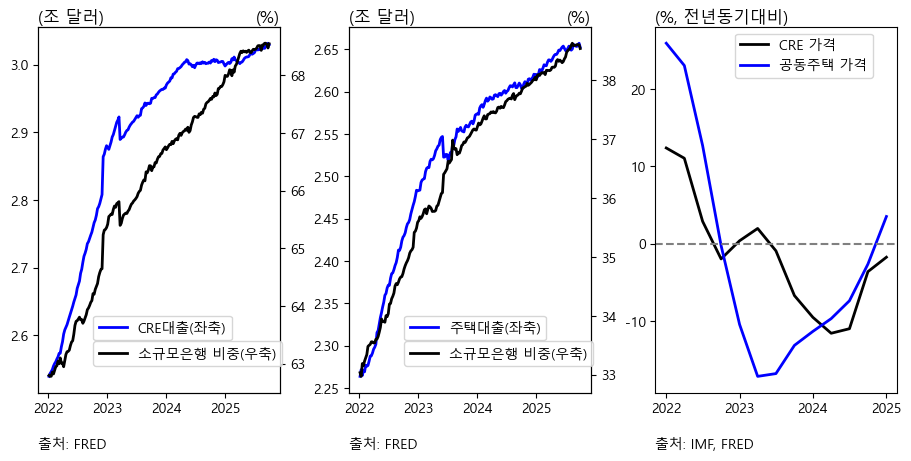

In [2]:

df_cre = fetch_fred_series('CREACBW027SBOG', start_date = start, end_date = end)
df_home = fetch_fred_series('RREACBW027SBOG', start_date = start, end_date = end)
df_credit = fetch_fred_series('TOTBKCR', start_date = start, end_date = end)
df_cre_small = fetch_fred_series('CRESCBW027SBOG', start_date = start, end_date = end)
df_home_small = fetch_fred_series('RRESCBW027SBOG', start_date = start, end_date = end)
df_price = fetch_fred_series('COMREPUSQ159N', start_date = start, end_date = end)

start_new = '2021-01-01'
end_new = '2025-01-31'

df_home_price = fetch_fred_series('BOGZ1FL075035403Q', start_date = start_new, end_date = end_new)
df_home_price['yoy'] = df_home_price["BOGZ1FL075035403Q"].pct_change(periods=4) * 100

# ##Merge on observation_date
df_merged = pd.merge(df_cre, df_credit, on='observation_date', how='inner')
df_merged = pd.merge(df_merged, df_home, on='observation_date', how='inner').copy()
df_merged = pd.merge(df_merged, df_cre_small, on='observation_date', how='inner')
df_merged = pd.merge(df_merged, df_home_small, on='observation_date', how='inner')
df_merged['ratio_cre'] = (df_merged['CREACBW027SBOG'] / df_merged['TOTBKCR']) * 100
df_merged['ratio_home'] = (df_merged['RREACBW027SBOG'] / df_merged['TOTBKCR']) * 100
df_merged['ratio_cre_small'] = (df_merged['CRESCBW027SBOG'] / df_merged['CREACBW027SBOG']) * 100
df_merged['ratio_home_small'] = (df_merged['RRESCBW027SBOG'] / df_merged['RREACBW027SBOG']) * 100

# Plotting
fig, ax = plt.subplots(1,3, figsize=(9, 4.5), constrained_layout=True)

ax_left = ax[0]
ax_right = ax_left.twinx()

ax_left.plot(df_merged['observation_date'], df_merged['CREACBW027SBOG']/1e3, label='CRE대출(좌축)', color='blue', lw=2)
ax_right.plot(df_merged['observation_date'], df_merged['ratio_cre_small'], label='소규모은행 비중(우축)', color='black', lw=2)
ax_left.legend(loc='upper left',bbox_to_anchor=(0.2, 0.23))
ax_right.legend(loc='upper left',bbox_to_anchor=(0.2, 0.16))


ax[0].xaxis.set_major_locator(mdates.YearLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 단위 표시 및 출처
ax_left.text(0, 1.00, '(조 달러)', ha='left', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[0].transAxes)
ax_right.text(1, 1.00, '(%)', ha='right', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[0].transAxes)
ax[0].text(0.0, -0.15, "출처: FRED", transform=ax[0].transAxes, fontsize=10, ha='left')
ax[0].grid(False)

ax_left1 = ax[1]
ax_right1 = ax_left1.twinx()

ax_left1.plot(df_merged['observation_date'], df_merged['RREACBW027SBOG']/1e3, label='주택대출(좌축)', color='blue', lw=2)
ax_right1.plot(df_merged['observation_date'], df_merged['ratio_home_small'], label='소규모은행 비중(우축)', color='black', lw=2)

ax_left1.legend(loc='upper left',bbox_to_anchor=(0.2, 0.23))
ax_right1.legend(loc='upper left',bbox_to_anchor=(0.2, 0.16))


ax[1].xaxis.set_major_locator(mdates.YearLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax_left1.text(0, 1.00, '(조 달러)', ha='left', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[1].transAxes)
ax_right1.text(1, 1.00, '(%)', ha='right', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[1].transAxes)

ax[1].text(0.0, -0.15, "출처: FRED", transform=ax[1].transAxes, fontsize=10, ha='left')
ax[1].grid(False)

# Plotting
ax[2].plot(df_price['observation_date'], df_price['COMREPUSQ159N'], label='CRE 가격', color='black', lw=2)
ax[2].plot(df_home_price['observation_date'], df_home_price['yoy'], label='공동주택 가격', color='blue', lw=2)
ax[2].axhline(y=0, color='gray', linestyle='--')

ax[2].legend(loc='upper left',bbox_to_anchor=(0.3, 1))
ax[2].xaxis.set_major_locator(mdates.YearLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 단위 표시 및 출처
ax[2].text(0, 1.00, '(%, 전년동기대비)', ha='left', va='bottom', color='black',
         fontsize=12, rotation=0, transform=ax[2].transAxes)
ax[2].text(0.0, -0.15, "출처: IMF, FRED", transform=ax[2].transAxes, fontsize=10, ha='left')
ax[2].grid(False)


# 저장 및 출력
# python py 파일 이름과 동일한 이름으로 그림 파일을 tif, jpg로 저장하는 루틴

plot_save()